In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
sys.path.append(str(Path().resolve().parent))
import multimin as mm
import time
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    surface_integral_P_X_CMND
    )

c:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\density_space_mapping\multimin.py:676: SyntaxWarning: invalid escape sequence '\s'
  N=(\sqrt{1+8f}-1)/2


In [3]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


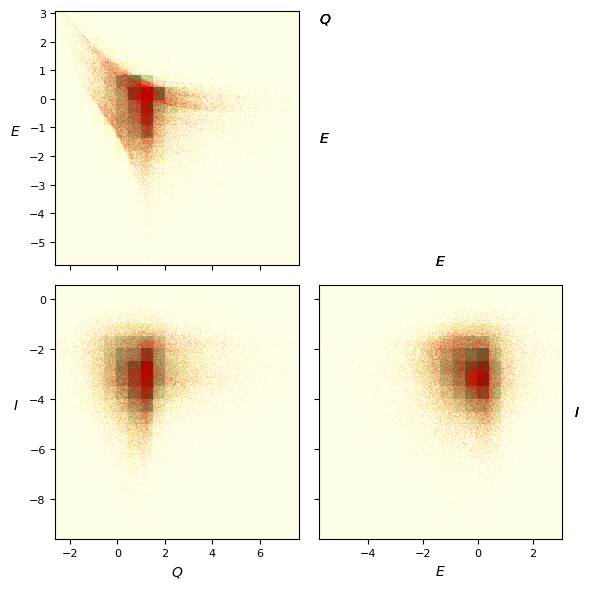

In [4]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [5]:
#max elements
max_elements = (1.3, 1.0, np.pi)

# Define center and widths of the phase-space hypercube
c_x = 0.9
c_y = 0.9
c_z = 0
v_x = 0
v_y = (mu/1)**0.5
v_z = 0

dxy = 0.1
dz = 0.5
dvxyz = 5000 * (1/AU_m) * year 

center = (c_x, c_y, c_z, v_x, v_y, v_z)
widths = (dxy, dxy, dz, dvxyz, dvxyz, dvxyz)

start_time = time.time()
#Theoretical: compute expected number of objects in the volume by integrating the distribution
N_theoretical = surface_integral_P_X_CMND(center, widths, max_elements=max_elements, n_points=8, mu=mu, F=F)
print(f"Theoretical (integral) number of objects in volume: {N_theoretical}")
print("--- %s seconds ---" % (time.time() - start_time))

Theoretical (integral) number of objects in volume: 1.0599344603424705e-06
--- 487.8625557422638 seconds ---


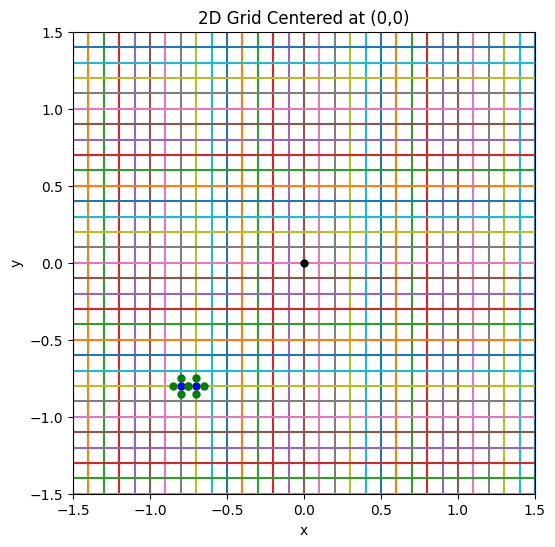

In [6]:
# grid parameters
xmin, xmax = -1.5, 1.5
ymin, ymax = -1.5, 1.5
dx, dy = 0.1, 0.1

# generate grid lines
x_lines = np.arange(xmin, xmax + dx, dx)
y_lines = np.arange(ymin, ymax + dy, dy)

plt.figure(figsize=(6, 6))

# draw vertical lines
for x in x_lines:
    plt.plot([x, x], [ymin, ymax])

# draw horizontal lines
for y in y_lines:
    plt.plot([xmin, xmax], [y, y])

originals = [x_lines[7], y_lines[7]]
originals2 = [x_lines[8], y_lines[7]]
box = [(originals[0] - 0.1/2, originals[0] + 0.1/2), (originals[1] - 0.1/2, originals[1] + 0.1/2)]
box2 = [(originals2[0] - 0.1/2, originals2[0] + 0.1/2), (originals2[1] - 0.1/2, originals2[1] + 0.1/2)]
plt.plot(0, 0, '.', color='black', markersize=10)
plt.plot(originals[0], originals[1], '.', color='blue', markersize=10)
plt.plot(originals2[0], originals2[1], '.', color='blue', markersize=10)
plt.plot(box[0][0], y_lines[7], '.', color='green', markersize=10)
plt.plot(box[0][1], y_lines[7], '.', color='green', markersize=10)
plt.plot(box2[0][0], y_lines[7], '.', color='green', markersize=10)
plt.plot(box2[0][1], y_lines[7], '.', color='green', markersize=10)
plt.plot(x_lines[7], box[1][0], '.', color='green', markersize=10)
plt.plot(x_lines[7], box[1][1], '.', color='green', markersize=10)
plt.plot(x_lines[8], box2[1][0], '.', color='green', markersize=10)
plt.plot(x_lines[8], box2[1][1], '.', color='green', markersize=10)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel("x")
plt.ylabel("y")
plt.title("2D Grid Centered at (0,0)")
plt.grid(False)

plt.show()

In [27]:
xmin, xmax = 0.4, 0.8
ymin, ymax = 0.4, 0.8
dx_grid = 0.1
dy_grid = 0.1

x_vals = np.arange(xmin, xmax + dx_grid, dx_grid)
y_vals = np.arange(ymin, ymax + dy_grid, dy_grid)

NX = len(x_vals)
NY = len(y_vals)

# Storage array for results
integral_grid = np.zeros((NX, NY))

fixed_z  = 0.0
fixed_vx = 0.0
fixed_vy = (mu/1)**0.5
fixed_vz = 0.0


dx = 0.1     # width in x
dy = 0.1     # width in y
dz = 0.5
dvx = 5000 * (1/AU_m) * year
dvy = 5000 * (1/AU_m) * year
dvz = 5000 * (1/AU_m) * year

widths = (dx, dy, dz, dvx, dvy, dvz)

max_elements = (1.3, 1.0, np.pi)  # <-- fill with your values

for ix, xv in enumerate(x_vals):
    for iy, yv in enumerate(y_vals):
        vy = (mu/np.abs(xv))**0.5
        center = (xv, yv, fixed_z, fixed_vx, vy, fixed_vz)
        print("evaluating at", center)
        print("widths", widths)

        try:
            val = surface_integral_P_X_CMND(
                center=center,
                widths=widths,
                max_elements=max_elements,
                n_points=8,    
                mu=mu,
                F=F           
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            val = np.nan

        integral_grid[ix, iy] = val

np.savetxt("P_X_grid_3.dat", integral_grid)
# Now integral_grid[i,j] holds the integral at (x_vals[i], y_vals[j])
print("Grid computed, shape =", integral_grid.shape)


evaluating at (np.float64(0.4), np.float64(0.4), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
evaluating at (np.float64(0.4), np.float64(0.5), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)


C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\utils\Utils.py:150: RuntimeWarning: invalid value encountered in scalar power
  return (1-e**2)**0.5
C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\utils\Utils.py:154: RuntimeWarning: invalid value encountered in scalar power
  return (mu*a)**0.5
C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\utils\Utils.py:733: RuntimeWarning: invalid value encountered in scalar power
  n = (mu/a**3)**0.5
C:\Users\INTERPLAY\Documents\juanita\repo\TesisRepo\utils\Utils.py:734: RuntimeWarning: invalid value encountered in scalar power
  factor = -(mu*a**3)**0.5/r**3


Runtime error at center = (np.float64(0.4), np.float64(0.5), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
   → Setting integral to NaN.
evaluating at (np.float64(0.4), np.float64(0.6), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
Runtime error at center = (np.float64(0.4), np.float64(0.6), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
   → Setting integral to NaN.
evaluating at (np.float64(0.4), np.float64(0.7), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
Runtime error at center = (np.float64(0.4), np.float64(0.7), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
   → Setting integral to NaN.
evaluating at (np.float64(0.4), np.float64(0.7999999999999999), 0.0, 0.0, np.float64(9.935912348802729), 0.0)
widths (0.1, 0.1, 0.5, 1.0547326203208556, 1.0547326203208556, 1.0547326203208556)
Runtime error at center = (np.float64(0.

### Grid 1: 
xmin, xmax = 0.9, 1.1 

ymin, ymax = 0.9, 1.1

Runtime error at center = (np.float64(0.9), np.float64(1.2), 0.0, 0.0, np.float64(6.623941565868487), 0.0)

In [12]:
integral_grid/(0.1*0.1)

array([[9.08581246e-05, 5.21359513e-05, 2.28373452e-05],
       [1.57980631e-04, 9.84362265e-05, 5.24896068e-05],
       [2.82944105e-04, 1.77795773e-04, 1.01469714e-04]])

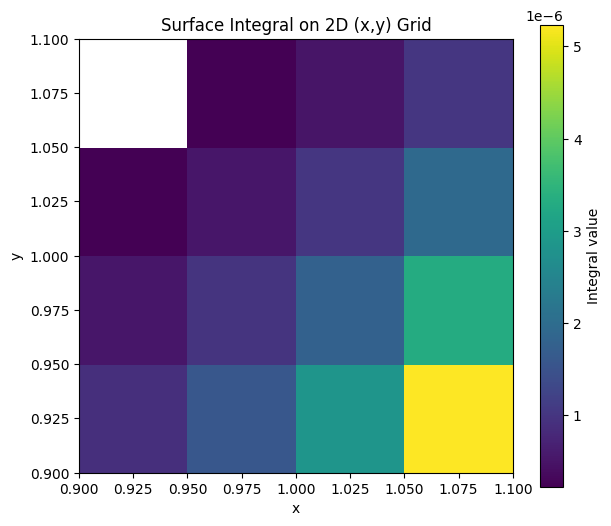

In [20]:
import matplotlib.pyplot as plt

with open("P_X_grid_1.dat", "rb") as f:
    integral_grid1 = np.loadtxt(f)

plt.figure(figsize=(7,6))
plt.imshow(integral_grid1.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax],
           aspect='equal')
plt.colorbar(label="Integral value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface Integral on 2D (x,y) Grid")
plt.show()

### Grid 2: 
xmin, xmax = 1.2, 1.5 

ymin, ymax = 1.2, 1.5

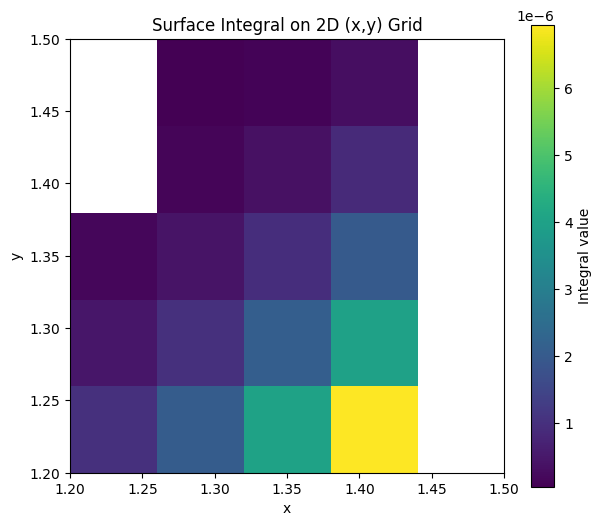

In [24]:
xmin, xmax = 1.2, 1.5
ymin, ymax = 1.2, 1.5

with open("P_X_grid_2.dat", "rb") as f:
    integral_grid2 = np.loadtxt(f)

plt.figure(figsize=(7,6))
plt.imshow(integral_grid2.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax],
           aspect='equal')
plt.colorbar(label="Integral value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface Integral on 2D (x,y) Grid")
plt.show()

In [25]:
integral_grid2

array([[1.01398270e-06, 4.57414765e-07, 1.76731660e-07,            nan,
                   nan],
       [2.06025175e-06, 9.92979563e-07, 4.11059787e-07, 1.48328720e-07,
        4.77028746e-08],
       [4.02411368e-06, 2.10689209e-06, 9.49067062e-07, 3.65208037e-07,
        1.23635065e-07],
       [6.94069474e-06, 4.00382290e-06, 2.01318797e-06, 8.62458140e-07,
        3.15463408e-07],
       [           nan,            nan,            nan,            nan,
                   nan]])

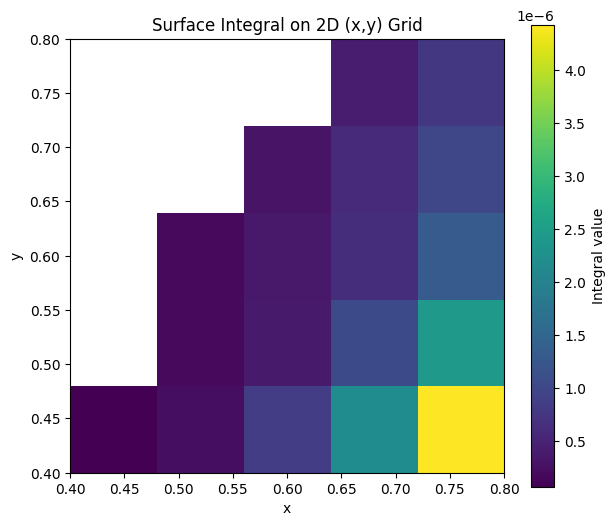

In [29]:
xmin, xmax = 0.4, 0.8
ymin, ymax = 0.4, 0.8

with open("P_X_grid_3.dat", "rb") as f:
    integral_grid3 = np.loadtxt(f)

plt.figure(figsize=(7,6))
plt.imshow(integral_grid3.T, origin='lower',
           extent=[xmin, xmax, ymin, ymax],
           aspect='equal')
plt.colorbar(label="Integral value")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface Integral on 2D (x,y) Grid")
plt.show()